# 07 - COVID-19 Country clustering

Which countries performed similarly during the pandemic, even if they are not in the same continent?

Here, we are going to analyze different patterns in the management-side of the pandemic, trying to identify group of countries that behaved similarly.

## Import Libraries

In [1]:
import os
from pathlib import Path

project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent
os.chdir(project_root)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import the data loader module
from src.data_loader import change_dtypes
from src.visualization import set_style

# Set visualization style
set_style(palette="Blues_d")

print('Libraries imported successfully!')

Libraries imported successfully!


## Load Data

In [3]:
countries = pd.read_csv("data/processed/countries.csv", parse_dates=["date"])
countries.head()

,country,date,total_cases,new_cases,new_cases_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths,new_deaths,...,continent,population,population_density,median_age,life_expectancy,gdp_per_capita,extreme_poverty,diabetes_prevalence,handwashing_facilities,hospital_beds_per_thousand
0,Afghanistan,2020-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Asia,40578847.0,62.215549,16.752001,65.616997,1516.273315,2.436315,10.9,51.938343,0.39
1,Afghanistan,2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Asia,40578847.0,62.215549,16.752001,65.616997,1516.273315,2.436315,10.9,51.938343,0.39
2,Afghanistan,2020-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Asia,40578847.0,62.215549,16.752001,65.616997,1516.273315,2.436315,10.9,51.938343,0.39
3,Afghanistan,2020-01-04,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,...,Asia,40578847.0,62.215549,16.752001,65.616997,1516.273315,2.436315,10.9,51.938343,0.39
4,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,...,Asia,40578847.0,62.215549,16.752001,65.616997,1516.273315,2.436315,10.9,51.938343,0.39


## Cluster Analysis

In [4]:
# Group by country and select the info we need
country_stats = (
    countries
    .groupby("country")
    .agg({
        'continent': 'first',
        'population': 'first',
        'gdp_per_capita': 'first',
        'median_age': 'first',
        'total_cases_per_million': 'max',
        'total_deaths_per_million': 'max',
        'people_fully_vaccinated_per_hundred': 'max'
    })
    .reset_index()
)

# We drop countries without data in population or total_deaths_per_million
country_stats = country_stats.dropna(subset=['total_deaths_per_million', 'population'])

print(f"Analysis dataset ready with {country_stats.shape[0]} countries.")
country_stats.head()

Analysis dataset ready with 232 countries.


,country,continent,population,gdp_per_capita,median_age,total_cases_per_million,total_deaths_per_million,people_fully_vaccinated_per_hundred
0,Afghanistan,Asia,40578847.0,1516.273315,16.752001,5295.3696,194.48557,34.659077
1,Albania,Europe,2827614.0,15492.067383,35.943001,118152.6200,1274.57290,45.168964
2,Algeria,Africa,45477391.0,11198.233398,27.983000,5974.6610,151.30595,14.251447
3,American Samoa,Oceania,48365.0,5579.981445,27.927000,172211.3100,702.98770,NaN
4,Andorra,Europe,79722.0,40223.011719,42.832001,601766.1000,1994.43070,67.103180


Now that we have all the data, we have to take into account some technical considerations:

* 1. **Variable Selection**

Clusters do not have the ability to select variables by themselves. We have to understand the "What for?" of our analysis and select the variables that can separate better our groups taking into account cluster vs profiling variables and avoid adding irrelevant noise.

It is better to start with few variables and then add more if we consider it proper.

We are going to start with these 3 variables:

* `median_age`: we demonstrated in the EDA it was the main risk factor.

* `gdp_per_capita`: proxy of sanitary resources and report capacity.

* `total_deaths_per_million`: the final measure of severity. 

<br>

2. **Algorithm Selection**

We are going to use K-Means because it is robust, interpretable and works well when the variables are continue and standardized. Also, it is complementary to the Shilouette Score measure in order to find the optimal number of groups.


> As clustering techniques do not work well with outliers and with different populations, we will filter our dataset to countries with more than 1M population.

In [5]:
from sklearn.preprocessing import StandardScaler

# 1. Feature Selection
features = ['median_age', 'gdp_per_capita', 'total_deaths_per_million']

# 2. Outlier Removal & Cleaning
# We keep only countries with Pop > 1M to remove micro-states noise
df_cluster = country_stats[country_stats['population'] > 1000000].copy()
df_cluster = df_cluster.dropna(subset=features)

# 3. Standardization (Z-Score)
# Critical step: GDP is in thousands, Age in tens. We need them on the same scale.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[features])

# Convert back to DataFrame for easier handling later
X_scaled_df = pd.DataFrame(X_scaled, columns=features, index=df_cluster.index)

print(f"Data ready for clustering: {X_scaled_df.shape[0]} countries.")
X_scaled_df.head()

Data ready for clustering: 158 countries.


,median_age,gdp_per_capita,total_deaths_per_million
0,-1.325192,-0.913879,-0.753427
1,0.681820,-0.261574,-0.004484
2,-0.150644,-0.461984,-0.783368
5,-1.363050,-0.708988,-0.850652
8,0.242162,0.063714,1.104112


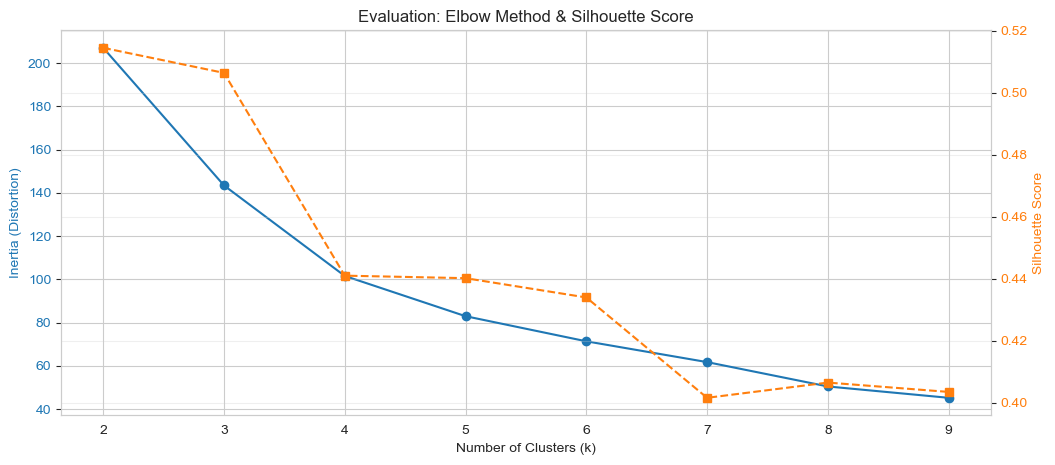

Based on Silhouette Score, the optimal k is likely: 2


In [13]:
# 2. Finding the Optimal Number of Clusters (K)
 
# We will use two methods to determine the best 'k':
# 1. **Elbow Method:** Looking for the point where inertia decreases significantly.
# 2. **Silhouette Score:** Measuring how similar an object is to its own cluster (cohesion) compared to other clusters (separation).

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette_scores = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10)
    kmeans.fit(X_scaled)
    
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plotting
fig, ax1 = plt.subplots(figsize=(12, 5))

# Plot 1: Elbow Method (Inertia)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Distortion)', color='tab:blue')
ax1.plot(K_range, inertia, marker='o', color='tab:blue', label='Inertia')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Plot 2: Silhouette Score
ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score', color='tab:orange')
ax2.plot(K_range, silhouette_scores, marker='s', linestyle='--', color='tab:orange', label='Silhouette')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title('Evaluation: Elbow Method & Silhouette Score')
plt.grid(True, alpha=0.3)
plt.show()

# Print the best score
best_k = K_range[silhouette_scores.index(max(silhouette_scores))]
print(f"Based on Silhouette Score, the optimal k is likely: {best_k}")

As the separation in 2 groups is a poor for the analysis, we are going to use the Inertia criteria and go for 4 clusters.

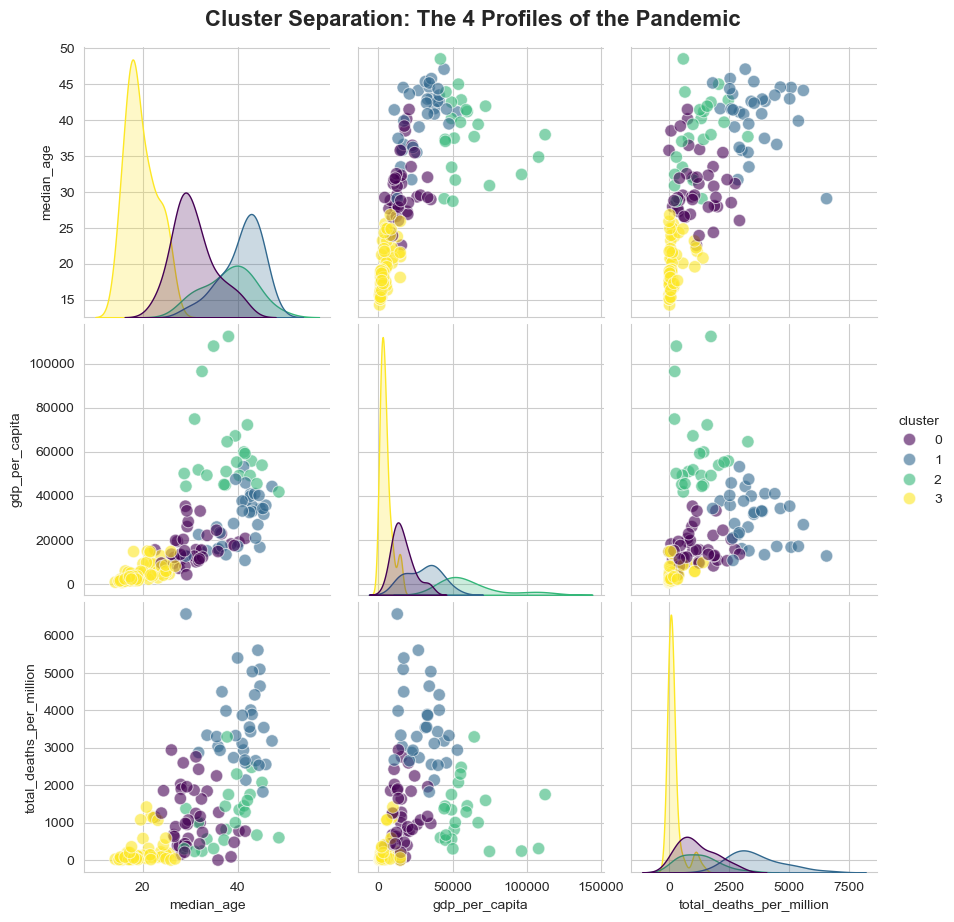

In [14]:
# 3. Cluster Execution (K=4)

# 1. Fit the Model with K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# 2. Add clusters back to the ORIGINAL dataframe (to see real values, not scaled ones)
df_cluster['cluster'] = clusters

# 3. Visualization: Pairplot
# This allows us to see how the clusters separate across all 3 dimensions
sns.pairplot(
    df_cluster, 
    vars=features, 
    hue='cluster', 
    palette='viridis',
    height=3,
    plot_kws={'alpha': 0.6, 's': 80}
)
plt.suptitle('Cluster Separation: The 4 Profiles of the Pandemic', y=1.02, fontsize=16, fontweight='bold')
plt.show()

**Cluster Interpretation (Profiling)**

Let's look at the average values of each group to give them a descriptive name.

In [24]:
# Group by cluster and calculate mean of features + count of countries
cluster_profile = (
    df_cluster
    .groupby('cluster')
    .agg({
        'median_age': 'mean',
        'gdp_per_capita': 'mean',
        'total_deaths_per_million': 'mean',
        'country': 'count' # To see how many countries are in each group
    })
    .sort_values('total_deaths_per_million', ascending=False) # Sort by severity
    .reset_index()
).set_index("cluster")

# Display nicely
display(cluster_profile.style.background_gradient(cmap='Reds', subset=['total_deaths_per_million']))

,median_age,gdp_per_capita,total_deaths_per_million,country
cluster,,,,
1,40.752281,30145.256226,3602.782247,32
2,38.076913,61026.655401,1233.329143,23
0,30.719550,16438.568542,1163.789673,40
3,19.687016,4879.686867,193.603106,63


Based on our analysis, we can clearly differentiate 4 distinct groups of countries:

* **Cluster 1: "The Critical Zone" (Old & Severe)**
    * **Characteristics:** Countries with the **highest median age (~41 years)** and a moderate GDP per capita (~$30k).
    * **Performance:** **Worst Performers**. They suffered the most deaths per million (~3,600). This group represents developed nations where the aging population combined with overwhelmed healthcare systems led to a catastrophe.

<br>

* **Cluster 2: "The Wealthy Fortress" (Old & Protected)**
    * **Characteristics:** **Rich countries (~$61k)** with a high median age (~38 years), similar to Cluster 1.
    * **Performance:** **Good Management**. Despite being "old" (vulnerable), they managed to keep deaths moderate (~1,200).
    * **Insight:** This proves that extreme wealth and resources *did* provide a layer of protection for vulnerable populations compared to Cluster 1.

<br>

* **Cluster 0: "The Developing Trap" (Young & Inefficient)**
    * **Characteristics:** Emerging economies with a **lower median age (~30 years)** and lower GDP (~$16k).
    * **Performance:** **Bad Management**. This is the most concerning group. They have **the same mortality rate (~1,100)** as Cluster 2, despite being almost **10 years younger!**
    * **Insight:** Their youth should have saved them, but poor healthcare infrastructure or management led to "excess deaths" relative to their demographics.

<br>

* **Cluster 3: "The Demographic Sanctuary" (Young & Shielded)**
    * **Characteristics:** The poorest countries (~$4k) with the **youngest population (~19 years)**.
    * **Performance:** **Natural Immunity**. They have the lowest death rates (~190).
    * **Insight:** The "Demographic Shield" is fully visible here. Biology (youth) acted as the strongest defense against severe COVID-19 outcomes.

In [ ]:
import plotly.express as px

# 1. Mapping
cluster_map = {
    1: 'Cluster 1: Critical Zone',
    2: 'Cluster 2: Wealthy Fortress',
    0: 'Cluster 0: Developing Trap',
    3: 'Cluster 3: Demographic Sanctuary'
}

if df_cluster['cluster'].dtype != 'object':
     df_cluster['cluster_name'] = df_cluster['cluster'].map(cluster_map)
else:
     df_cluster['cluster_name'] = df_cluster['cluster']

# 2. Map settings
fig = px.choropleth(
    df_cluster,
    locations="country",
    locationmode='country names',
    color="cluster_name",
    
    # --- TOOLTIP ---
    hover_name="country", # Bold title
    hover_data={
        'cluster_name': False, # Hide
        'country': False,      # Hide
        'total_deaths_per_million': ':,.0f', # Format: 1,234 (without decimals)
        'median_age': ':.1f',                # Format: 42.5 (1 decimal)
        'gdp_per_capita': ':,.0f'            # Format: 30,000 (without decimals)
    },
    labels={ # Rename variables
        'total_deaths_per_million': 'Deaths per Million',
        'median_age': 'Median Age',
        'gdp_per_capita': 'GDP per Capita ($)',
        'cluster_name': 'Group Profile'
    },
    # --------------------------------------
    
    # Personalized colors
    color_discrete_map={
        'Cluster 1: Critical Zone': '#d62728',       # Red
        'Cluster 0: Developing Trap': '#ff7f0e',     # Orange
        'Cluster 2: Wealthy Fortress': '#1f77b4',    # Blue
        'Cluster 3: Demographic Sanctuary': '#2ca02c'# Green
    },
    title="<b>Global Cluster Analysis:</b> Structural Similarities in the Pandemic"
)

# Final adjustments
fig.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='equirectangular',
        coastlinecolor="RebeccaPurple",
        showland=True,
        landcolor="lightgray"
    ),
    margin={"r":0,"t":40,"l":0,"b":0},
    legend=dict(title="Pandemic Profile", y=0.05, x=0.05)
)

fig.show()

/var/folders/kx/v0sncs2n15df2sfx78b0jv700000gn/T/ipykernel_68450/2515377725.py:18: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.

